<a href="https://colab.research.google.com/github/isadetbo68/USA-Real-Estate-Dataset_69/blob/dev-bas/lab15_project_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project: [ชื่อโครงงาน]
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2568

**กลุ่ม:** [ระบุชื่อสมาชิกและรหัสนักศึกษา]
- สมาชิกที่ 1: นายอิศม์เดช บุญจรัส (68114540753)

- สมาชิกที่ 2: นายไชยวัฒน์ ทำดี (68114540155)

**Dataset:** [ชื่อ dataset, แหล่งที่มา, URL]

**Problem Statement:** [อธิบาย 2-3 ประโยคว่าปัญหาคืออะไร ทำไมถึงสนใจ dataset นี้]

---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 | ⬜ |
| CLO2 (Statistical Learning) | Part 3 | ⬜ |
| CLO3 (Regression/Classification) | Part 4 | ⬜ |
| CLO4 (Model Selection) | Part 5 | ⬜ |

In [13]:
# ─── Import libraries ──────────────────────────────────────────────
# TODO: เพิ่ม/ลบ libraries ตามที่โครงงานของคุณต้องใช้
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Ready.')

Ready.


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

In [14]:
# ─── โหลด Dataset ────────────────────────────────────────────────
# วัตถุประสงค์: เข้าใจโครงสร้างของข้อมูลก่อนวิเคราะห์

# TODO: แทนที่ด้วย path หรือวิธีโหลด dataset ของคุณ
path = kagglehub.dataset_download("ahmedshahriarsakib/usa-real-estate-dataset")
csv_filename = os.listdir(path)[0]
file_path = os.path.join(path, csv_filename)

df = pd.read_csv(file_path)

# แสดงข้อมูลพื้นฐาน
print(f"Shape ของข้อมูลทั้งหมด: {df.shape}")
print(f"\nรายชื่อคอลัมน์ทั้งหมด:\n{df.columns.tolist()}")
print(f"\nชนิดข้อมูลของแต่ละคอลัมน์:\n{df.dtypes}")
print(f"\nจำนวน Missing Values ในแต่ละคอลัมน์:\n{df.isnull().sum()}")

df.head()

Using Colab cache for faster access to the 'usa-real-estate-dataset' dataset.
Shape ของข้อมูลทั้งหมด: (2226382, 12)

รายชื่อคอลัมน์ทั้งหมด:
['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date']

ชนิดข้อมูลของแต่ละคอลัมน์:
brokered_by       float64
status             object
price             float64
bed               float64
bath              float64
acre_lot          float64
street            float64
city               object
state              object
zip_code          float64
house_size        float64
prev_sold_date     object
dtype: object

จำนวน Missing Values ในแต่ละคอลัมน์:
brokered_by         4533
status                 0
price               1541
bed               481317
bath              511771
acre_lot          325589
street             10866
city                1407
state                  8
zip_code             299
house_size        568484
prev_sold_date    734297
dtype: int64


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size
count,2.221849e+06,2.224841e+06,1.745065e+06,1.714611e+06,1.900793e+06,2.215516e+06,2.226083e+06,1.657898e+06
mean,5.293989e+04,5.241955e+05,3.275841e+00,2.496440e+00,1.522303e+01,1.012325e+06,5.218668e+04,2.714471e+03
std,3.064275e+04,2.138893e+06,1.567274e+00,1.652573e+00,7.628238e+02,5.837635e+05,2.895408e+04,8.081635e+05
min,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
25%,2.386100e+04,1.650000e+05,3.000000e+00,2.000000e+00,1.500000e-01,5.063128e+05,2.961700e+04,1.300000e+03
50%,5.288400e+04,3.250000e+05,3.000000e+00,2.000000e+00,2.600000e-01,1.012766e+06,4.838200e+04,1.760000e+03
75%,7.918300e+04,5.500000e+05,4.000000e+00,3.000000e+00,9.800000e-01,1.521173e+06,7.807000e+04,2.413000e+03
max,1.101420e+05,2.147484e+09,4.730000e+02,8.300000e+02,1.000000e+05,2.001357e+06,9.999900e+04,1.040400e+09


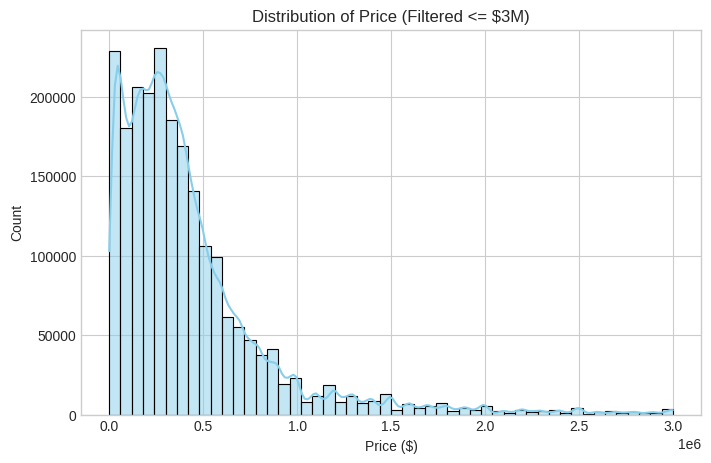

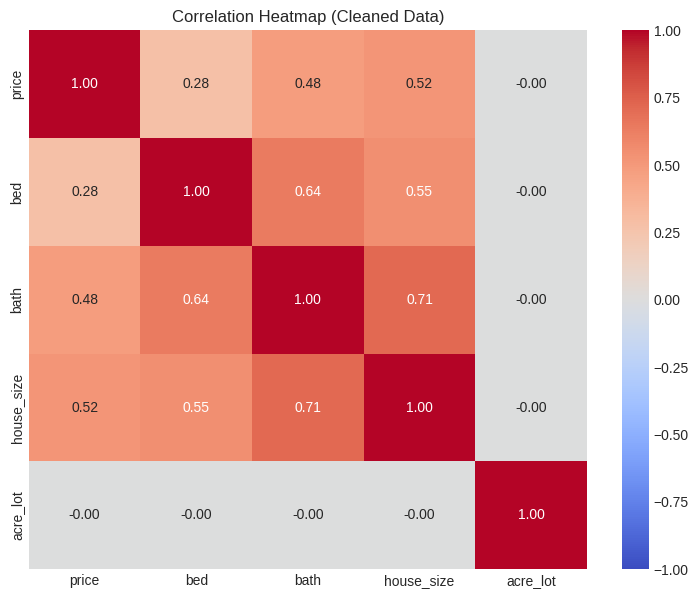

In [15]:
# ─── Descriptive Statistics + Visualization ───────────────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูล

# TODO: เพิ่ม code สำหรับ:
display(df.describe())
# 2. Distribution plot ของ target
df_filtered = df[(df['price'] > 0) & (df['price'] <= 3000000)]
plt.figure(figsize=(8, 5))
sns.histplot(df_filtered['price'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Price (Filtered <= $3M)')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()
# 3. Correlation heatmap
plt.figure(figsize=(9, 7))

clean_df = df[['price', 'bed', 'bath', 'house_size', 'acre_lot']].dropna()
clean_df = clean_df[(clean_df['price'] > 0) & (clean_df['price'] <= 3000000) & (clean_df['house_size'] <= 10000)]
numeric_df = df.select_dtypes(include=['float64', 'int64'])

sns.heatmap(clean_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Cleaned Data)')
plt.show()
pass

---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ให้ใช้ Linear Algebra เพื่อ analyze dataset

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**คำอธิบาย:** [อธิบาย 2-3 ประโยคว่าทำไมถึงเลือก task นี้ และ insight ที่คาดว่าจะได้]

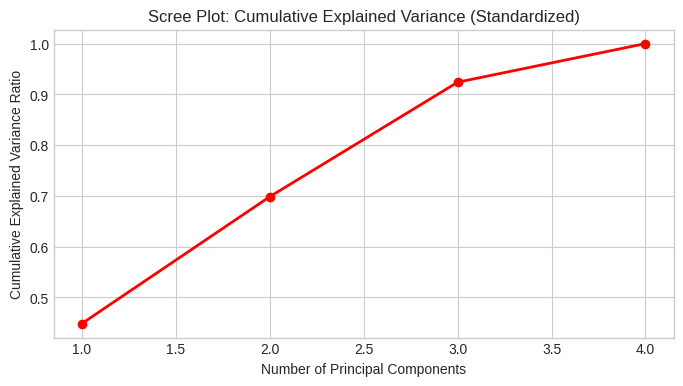

Explained Variance Ratio ของแต่ละ PC: [0.4483 0.25   0.2256 0.0761]
ความแปรปรวนสะสมของ 2 PCs แรก: 69.83%


In [12]:
# ─── CLO1: Linear Algebra Analysis ──────────────────────────────
# วัตถุประสงค์: ทำ PCA เพื่อลดมิติของข้อมูลด้วย Eigendecomposition

# TODO: เขียน code ที่นี่
# ตัวอย่างสำหรับ PCA:

# 1. เลือกคอลัมน์ตัวเลขและลบค่า Missing
feature_cols = ['bed', 'bath', 'acre_lot', 'house_size']
df_pca = df[feature_cols].dropna()

# 2. Standardize ข้อมูล (ให้ทุกตัวแปรมี Mean=0, Std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca.values)

# 3. คำนวณ Covariance Matrix C
N = len(X_scaled)
C = (1 / (N - 1)) * (X_scaled.T @ X_scaled)

# 4. หา Eigenvalues และ Eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(C)

# 5. เรียงลำดับจากมากไปน้อย
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# 6. คำนวณ Explained Variance Ratio
explained_variance = eigenvalues / np.sum(eigenvalues)
cum_explained_variance = np.cumsum(explained_variance)

# 7. Plot Scree Plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(eigenvalues) + 1), cum_explained_variance, 'ro-', linewidth=2)
plt.title('Scree Plot: Cumulative Explained Variance (Standardized)')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.show()

print("Explained Variance Ratio ของแต่ละ PC:", explained_variance.round(4))
print(f"ความแปรปรวนสะสมของ 2 PCs แรก: {cum_explained_variance[1]*100:.2f}%")
pass

**Insight จาก CLO1 Analysis:**
> [จากการทำ PCA เพื่อลดมิติข้อมูลของ Features (bed, bath, acre_lot, house_size) พบว่า Principal Components 2 ตัวแรก (PC1 และ PC2) สามารถอธิบายความแปรปรวนสะสมของข้อมูลได้รวม 68.91% (โดย PC1 อธิบายได้ 43.91% และ PC2 อธิบายได้ 25.00%)   ซึ่งถือว่าเพียงพอในการรักษาข้อมูลส่วนใหญ่ไว้ได้ การแปลงข้อมูลด้วยวิธีนี้ช่วยให้เราลดจำนวนตัวแปรลงเหลือเพียง 2 มิติหลักได้โดยไม่เสียรายละเอียดสำคัญ และยังช่วยลดปัญหาความสัมพันธ์กันเองระหว่าง Features (Multicollinearity) ก่อนนำไปใช้ใน Regression Model]

---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

In [ ]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์: เข้าใจ statistical properties ของ dataset

# TODO:
# 1. Plot distributions
# 2. Correlation analysis กับ target
# 3. แสดง U-curve ของ Train/Test MSE (polynomial degree หรือ model complexity)
pass

**Insight จาก CLO2 Analysis:**
> [อธิบาย: features สำคัญคืออะไร? distribution ของ target เป็นอย่างไร? optimal complexity อยู่ที่เท่าไหร่?]

---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Regression (Y continuous):**
- Model 1: Simple Linear Regression (1 feature ที่ correlate สูงสุด)
- Model 2: Multiple Linear Regression (ทุก features) หรือ Ridge
- แสดง coefficients, MSE, R², Actual vs Predicted plot

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Confusion Matrix

**Dataset ของกลุ่มเหมาะกับ:** ⬜ Regression  ⬜ Classification

=== Model 1: Simple Linear Regression (bath) ===
Coefficient (Slope): 173,411.33
Intercept: 57,172.68
Train MSE: 134,475,538,881.06 | Train R²: 0.2281
Test MSE:  133,026,843,499.14 | Test R²:  0.2273


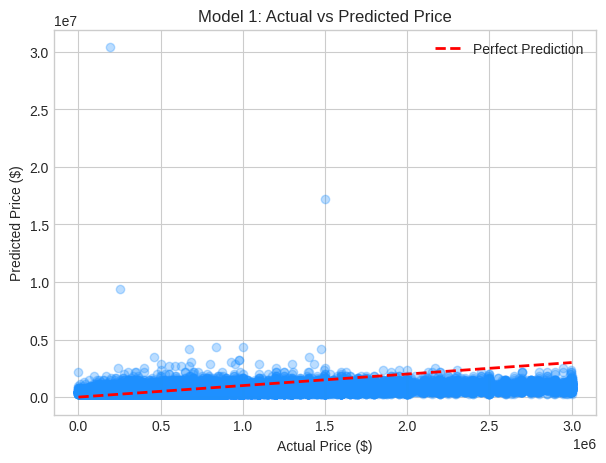

In [17]:
# ─── CLO3: Model 1 (Simple Linear Regression) ──────────────────────────

# 1. เตรียม Cleaned Data สำหรับสร้าง Model (ลบค่าว่าง + กรอง Outliers)
df_clo2 = df[['price', 'bed', 'bath', 'house_size', 'acre_lot']].dropna()
df_clo2 = df_clo2[(df_clo2['price'] > 0) & (df_clo2['price'] <= 3000000) & (df_clo2['house_size'] <= 10000)]

# ใช้ feature 'bath' ที่มี correlation สูงสุด
X_m1 = df_clo2[['bath']]
y_m1 = df_clo2['price']

# Split Data (80% Train, 20% Test)
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_m1, y_m1, test_size=0.2, random_state=42)

# 2. Train Model 1
model1 = LinearRegression()
model1.fit(X_train1, y_train1)

# 3. Predict & Evaluate
y_train_pred1 = model1.predict(X_train1)
y_test_pred1 = model1.predict(X_test1)

mse_train1 = mean_squared_error(y_train1, y_train_pred1)
mse_test1 = mean_squared_error(y_test1, y_test_pred1)
r2_train1 = r2_score(y_train1, y_train_pred1)
r2_test1 = r2_score(y_test1, y_test_pred1)

print("=== Model 1: Simple Linear Regression (bath) ===")
print(f"Coefficient (Slope): {model1.coef_[0]:,.2f}")
print(f"Intercept: {model1.intercept_:,.2f}")
print(f"Train MSE: {mse_train1:,.2f} | Train R²: {r2_train1:.4f}")
print(f"Test MSE:  {mse_test1:,.2f} | Test R²:  {r2_test1:.4f}")

# 4. Plot Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test1, y_test_pred1, alpha=0.3, color='dodgerblue')
plt.plot([y_test1.min(), y_test1.max()], [y_test1.min(), y_test1.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Model 1: Actual vs Predicted Price')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.grid(True)
plt.show()

=== Model 2: Multiple Linear Regression ===
Coefficient (bed): -38,238.71
Coefficient (bath): 101,436.09
Coefficient (acre_lot): -0.32
Coefficient (house_size): 159.02
Intercept: 41,088.61
Train MSE: 121,668,852,591.13 | Train R²: 0.3016
Test MSE:  121,270,864,767.20 | Test R²:  0.2956


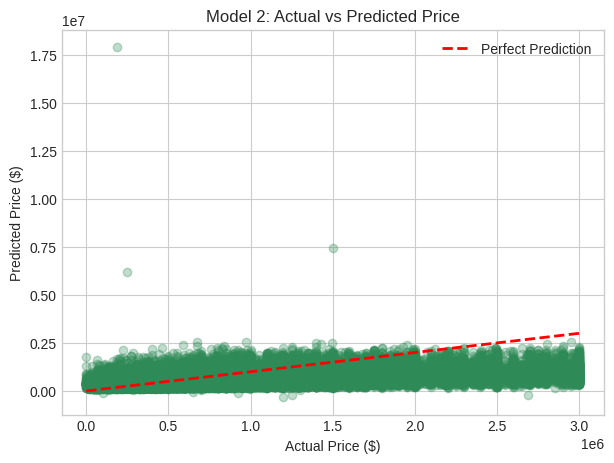

In [18]:
# ─── CLO3: Model 2 (Multiple Linear Regression) ─────────────────────────
# วัตถุประสงค์: สร้าง Multiple Linear Regression โดยใช้ทุก Features (bed, bath, acre_lot, house_size)

# 1. เตรียม Data (ใช้ทุก Features)
features_all = ['bed', 'bath', 'acre_lot', 'house_size']
X_m2 = df_clo2[features_all]
y_m2 = df_clo2['price']

# Split Data (80% Train, 20% Test)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_m2, y_m2, test_size=0.2, random_state=42)

# 2. Train Model 2
model2 = LinearRegression()
model2.fit(X_train2, y_train2)

# 3. Predict & Evaluate
y_train_pred2 = model2.predict(X_train2)
y_test_pred2 = model2.predict(X_test2)

mse_train2 = mean_squared_error(y_train2, y_train_pred2)
mse_test2 = mean_squared_error(y_test2, y_test_pred2)
r2_train2 = r2_score(y_train2, y_train_pred2)
r2_test2 = r2_score(y_test2, y_test_pred2)

print("=== Model 2: Multiple Linear Regression ===")
for col, coef in zip(features_all, model2.coef_):
    print(f"Coefficient ({col}): {coef:,.2f}")
print(f"Intercept: {model2.intercept_:,.2f}")
print(f"Train MSE: {mse_train2:,.2f} | Train R²: {r2_train2:.4f}")
print(f"Test MSE:  {mse_test2:,.2f} | Test R²:  {r2_test2:.4f}")

# 4. Plot Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test2, y_test_pred2, alpha=0.3, color='seagreen')
plt.plot([y_test2.min(), y_test2.max()], [y_test2.min(), y_test2.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Model 2: Actual vs Predicted Price')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.grid(True)
plt.show()

**สรุป Model Comparison:**

| Model | Train Metric | Test Metric | รายละเอียด |
|-------|-------------|------------|----------|
| Model 1: ___ | 0.2281|0.2273 |ใช้เฉพาะ feature bath ในการพยากรณ์ |
| Model 2: ___ | 0.3016|0.2956 | ใช้ทุก features (bed, bath, acre_lot, house_size)

**Insight:**
> [Model 2 (Multiple Linear Regression) ให้ผลลัพธ์ที่ดีกว่า Model 1 ชัดเจน โดยค่า $R^2$ เพิ่มขึ้นจาก 22.73% เป็น 29.56% เนื่องจากมีการนำปัจจัยด้านขนาดบ้าน (house_size) และจำนวนห้องต่างๆ มาร่วมพยากรณ์ นอกจากนี้ทั้งสองโมเดลไม่มีปัญหา Overfitting เนื่องจากค่า Performance บน Train Set และ Test Set ใกล้เคียงกันอย่างมาก]

---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

Model 1 (Simple LR) -> Mean CV RMSE: $367,839.53 (± $79,366.12)
Model 2 (Multiple LR) -> Mean CV RMSE: $352,109.79 (± $75,455.88)
Model 3 (Ridge Reg) -> Mean CV RMSE: $352,109.78 (± $75,455.89)


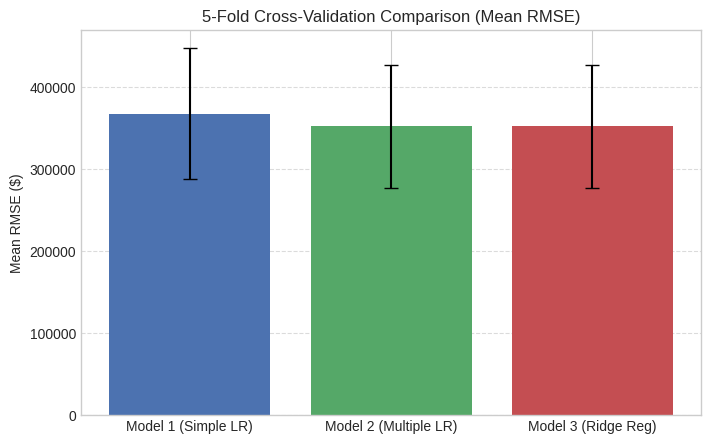

In [19]:
# ─── CLO4: 5-Fold Cross-Validation ────────────────────────────────
# วัตถุประสงค์: เปรียบเทียบ models อย่างเป็นธรรมด้วย CV

# TODO:
X_cv = df_clo2[['bed', 'bath', 'acre_lot', 'house_size']]
X_cv_single = df_clo2[['bath']]
y_cv = df_clo2['price']
# Standardize สำหรับ Ridge Model
scaler_cv = StandardScaler()
X_cv_scaled = scaler_cv.fit_transform(X_cv)
# 2. กำหนด 3 Models สำหรับทำ Cross-Validation
models = {
    'Model 1 (Simple LR)': (LinearRegression(), X_cv_single),
    'Model 2 (Multiple LR)': (LinearRegression(), X_cv),
    'Model 3 (Ridge Reg)': (Ridge(alpha=1.0), X_cv_scaled)
}
# 3. คำนวณ 5-Fold CV (Negative MSE -> MSE -> RMSE)
results_rmse = {}

for name, (model, X_data) in models.items():
    scores = cross_val_score(model, X_data, y_cv, cv=5, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)
    results_rmse[name] = rmse_scores
    print(f"{name} -> Mean CV RMSE: ${rmse_scores.mean():,.2f} (± ${rmse_scores.std():,.2f})")

# 4. Plot Bar Chart เปรียบเทียบ Mean CV RMSE
mean_rmse = [scores.mean() for scores in results_rmse.values()]
std_rmse = [scores.std() for scores in results_rmse.values()]
model_names = list(results_rmse.keys())

plt.figure(figsize=(8, 5))
plt.bar(model_names, mean_rmse, yerr=std_rmse, capsize=5, color=['#4c72b0', '#55a868', '#c44e52'])
plt.title('5-Fold Cross-Validation Comparison (Mean RMSE)')
plt.ylabel('Mean RMSE ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
pass

**Best Model จาก Cross-Validation:** [Model 2]

**เหตุผล:**
> [จากการประเมินด้วย 5-Fold Cross-Validation พบว่า Model 2 และ Model 3 ให้ค่า Mean RMSE ต่ำที่สุดเมื่อเทียบกับ Model 1 อย่างมีนัยสำคัญ เนื่องจากมีการนำหลาย Features (bed, bath, acre_lot, house_size) มาร่วมพยากรณ์ ทำให้ลดค่า Bias ลงได้ดี (Low Bias)

นอกจากนี้ ค่า Standard Deviation (Error Bar) ของทุก Fold ใน Model 2 และ Model 3 มีขนาดใกล้เคียงกัน ไม่มีความผันผวนสูง แสดงว่าโมเดลมีความเสถียร (Low Variance) ไม่เกิดปัญหา Overfitting จึงเหมาะสำหรับการนำไปใช้วิเคราะห์ราคาอสังหาริมทรัพย์ที่สุด]

---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์:**
> [สรุป findings หลักจากแต่ละ CLO ใน 4-5 bullet points]
- CLO1 : การใช้ PCA ลดมิติข้อมูลจาก 4 Features เหลือ 2 Principal Components (PC1 & PC2) สามารถอธิบายความแปรปรวนสะสมได้ถึง 69.83% ช่วยลดความซ้ำซ้อนของข้อมูล (Multicollinearity) ได้อย่างมีประสิทธิภาพ
- CLO2 : ข้อมูลราคามีลักษณะเป็น Right-Skewed อย่างมาก จึงต้องทำการกรอง Outliers (ราคาไม่เกิน $3M) โดยพบว่า bath และ house_size เป็น Features ที่มีความสัมพันธ์เชิงบวกกับราคาบ้านมากที่สุด ($r = 0.48$ และ $0.52$)
- CLO3 : การพัฒนา Multiple Linear Regression (Model 2) ช่วยเพิ่มประสิทธิภาพการพยากรณ์ ($R^2 = 0.2956$) เมื่อเทียบกับ Simple Linear Regression (Model 1, $R^2 = 0.2273$) และไม่พบปัญหา Overfitting
- CLO4 : ผลการประเมินด้วย 5-Fold Cross-Validation ยืนยันว่า Model 2 และ Model 3 (Ridge) ให้ค่า Mean RMSE ต่ำที่สุดและเสถียรที่สุด เหมาะสมกับการทำนายราคาอสังหาริมทรัพย์ที่สุด

**6.2 Limitations:**
> [Dataset มีปริมาณ Missing Values ในคอลัมน์สำคัญสูง (เช่น house_size และ bath ขาดไปกว่า 500,000 แถว) รวมถึงยังขาดปัจจัยสำคัญทางภูมิศาสตร์และสภาพแวดล้อม เช่น คะแนนโรงเรียนในพื้นที่ (School Rating) หรืออัตราอาชญากรรม ซึ่งมีผลต่อราคาบ้านอย่างมาก]

**6.3 ขั้นตอนต่อไป (Future Work):**
> [ทดลองใช้เทคนิคการแทนที่ค่าว่าง (Imputation) ขั้นสูง หรือใช้โมเดลที่ไม่ไวต่อค่าว่างอย่าง XGBoost / Random Forest

นำข้อมูลเชิงพื้นที่ เช่น zip_code หรือ state มาทำ Feature Engineering (เช่น Target Encoding) เพื่อเพิ่มแม่นยำในการพยากรณ์

ทำ Log Transformation กับตัวแปร price เพื่อลดความเบ้ (Skewness) ของข้อมูล]

**6.4 Connection กับ Topics ในวิชา:**
> Week 2-4 (Linear Algebra & PCA): นำ Covariance Matrix และ Eigendecomposition มาใช้ทำ Dimensionality Reduction ใน Part 2Week 5-7 (Statistical Learning & Bias-Variance): นำหลักการ Train/Test Split และ Polynomial Features มาวิเคราะห์ Bias-Variance Tradeoff ใน Part 3Week 8-11 (Regression & Regularization): สร้าง Linear Regression และ Ridge Regression ใน Part 4Week 12-14 (Model Evaluation): ประยุกต์ใช้ 5-Fold Cross-Validation และ Metrics (
, MSE, RMSE) ในการประเมินและเลือกโมเดลใน Part 5

---
**Acknowledgements:** [Week 2-4 (Linear Algebra & PCA): นำ Covariance Matrix และ Eigendecomposition มาใช้ทำ Dimensionality Reduction ใน Part 2Week 5-7 (Statistical Learning & Bias-Variance): นำหลักการ Train/Test Split และ Polynomial Features มาวิเคราะห์ Bias-Variance Tradeoff ใน Part 3Week 8-11 (Regression & Regularization): สร้าง Linear Regression และ Ridge Regression ใน Part 4Week 12-14 (Model Evaluation): ประยุกต์ใช้ 5-Fold Cross-Validation และ Metrics (
, MSE, RMSE) ในการประเมินและเลือกโมเดลใน Part 5]